## Simple Linear Regression

### Problem Statement: 
### To predict the height of an individual based on his or her weight.

### Dataset Overview: 
- 2 features: Height(cms) and Weight(kgs)
- 50 rows

In [6]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') #plot theme

RANDOM_STATE = 42

In [7]:
# importing dataset
df = pd.read_csv('../Datasets/height-weight.csv')

In [8]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

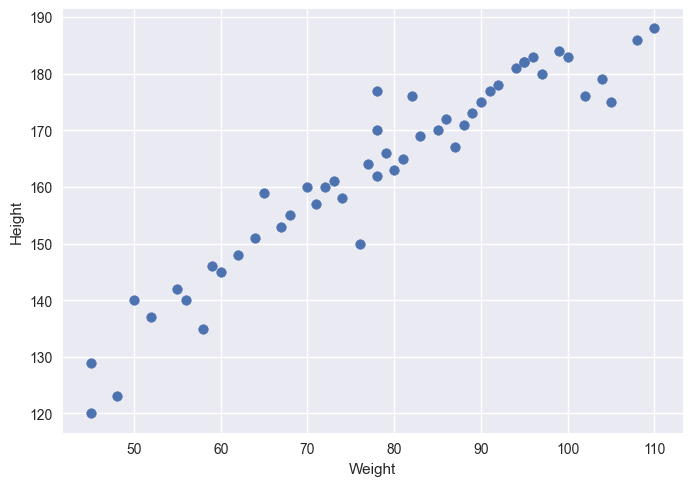

In [9]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [10]:
## Correlation between features
df.corr()

,Weight,Height
Weight,1.000000,0.949943
Height,0.949943,1.000000


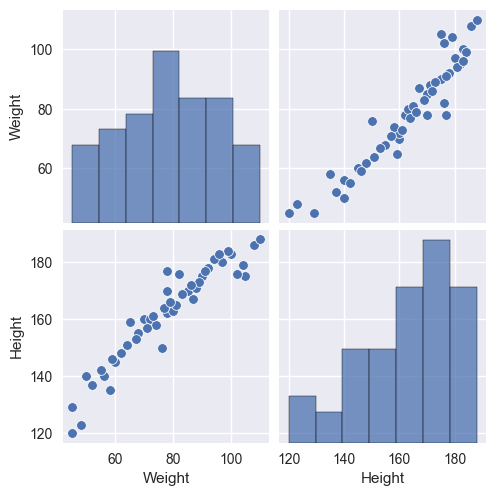

In [11]:
sns.pairplot(df)

In [12]:
## Defining Independent and Dependent Features

X = df[['Weight']] ## independent feature should be a 2d array
y = df['Height']

In [13]:
print(f"X_shape: {np.array(X).shape} \ny_shape: {np.array(y).shape}")

X_shape: (50, 1) 
y_shape: (50,)


In [14]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

In [15]:
X_train

,Weight
12,105
4,70
37,83
8,95
3,60
6,80
41,104
46,86
47,91
15,78


In [16]:
## Standardization 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train # standardized values

array([[ 1.53932584],
       [-0.42696629],
       [ 0.30337079],
       [ 0.97752809],
       [-0.98876404],
       [ 0.13483146],
       [ 1.48314607],
       [ 0.47191011],
       [ 0.75280899],
       [ 0.02247191],
       [ 0.02247191],
       [-1.5505618 ],
       [-0.87640449],
       [-0.76404494],
       [ 1.37078652],
       [-1.83146067],
       [-0.25842697],
       [ 0.19101124],
       [-1.04494382],
       [ 0.02247191],
       [ 0.80898876],
       [ 0.97752809],
       [-0.03370787],
       [-1.1011236 ],
       [-1.21348315],
       [-1.66292135],
       [-0.59550562],
       [-0.37078652],
       [-1.43820225],
       [ 1.20224719],
       [ 0.24719101],
       [-0.31460674],
       [-0.08988764],
       [ 1.82022472],
       [-1.83146067],
       [ 0.69662921],
       [ 1.70786517],
       [ 0.41573034],
       [ 0.58426966],
       [ 0.64044944]])

In [18]:
## Apply Linear Regression
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [19]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print(f"Coeffiecient or Slope: {regression.coef_}")
print(f"Intercept: {regression.intercept_}")

Coeffiecient or Slope: [16.79016854]
Intercept: 161.725


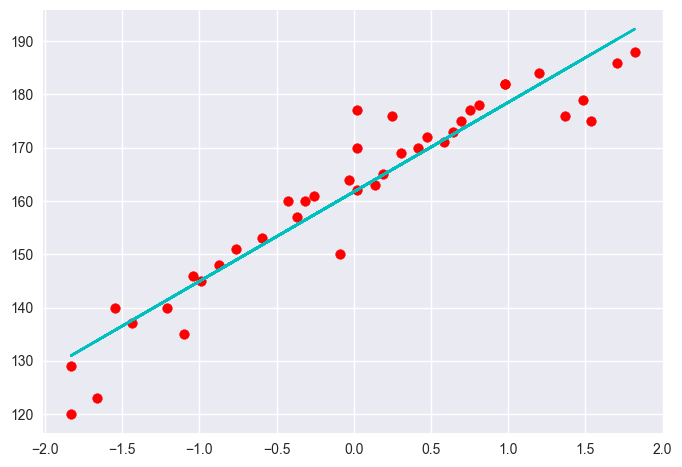

In [21]:
## Plotting Training Data and Best Fit Line
plt.scatter(X_train, y_train, color='r')
plt.plot(X_train, regression.predict(X_train), color='c')

#### Predicting Test Data

In [22]:
y_pred = regression.predict(X_test)
print(y_pred)

[182.85420086 177.19459349 180.02439717 163.04557505 149.83982452
 179.08112928 158.32923558 152.6696282  140.40714556 170.59171822]


#### Performance Metrices

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Squared Error: 14.347461452569297
Mean Absolute Error: 2.7853254008332273
Root Mean Squared Error: 3.7878043049462438


In [24]:
from sklearn.metrics import r2_score

r_sq_score = r2_score(y_test, y_pred)
print(f"R-Squrared = {r_sq_score}")

adj_r_sq_error = 1 - (1-r_sq_score)*(len(y_test)-1)/(len(y_test) - X_test.shape[-1]-1)
print(f"Adjusted R-Squared = {adj_r_sq_error}")

R-Squrared = 0.9198644914400732
Adjusted R-Squared = 0.9098475528700823


#### Prediction on new data

In [25]:
input_weight = input('Enter the Weight of an individual in Kgs: ')
new_data = pd.DataFrame({'Weight': [input_weight]}) #avoids feature name user warning

predicted_height = regression.predict(scaler.transform(new_data))
                                                      
print()
                                                       
print(f"Weight:{input_weight}Kgs ---> Height:{predicted_height}cms")


Weight:25Kgs ---> Height:[112.1091087]cms
